In [58]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from matplotlib import pyplot as plt
import seaborn as sns

In [59]:
df = pd.read_csv('./results/cleaned_shipment_classification_dataset.csv')

In [60]:
# columns_to_drop = ['item_size']
# df = df.drop(columns=columns_to_drop)

In [61]:
df[df['shipment_classified']== '']

,quantity_in,batch_created_time,bill_date,b.coo,shipping_port,shipped_date,due_date,eta,customs_broker,b.payment_terms,scac,tariff_amount,bill_status,sku,brand,manufacturer,shipment_classified


In [62]:
df.columns

Index(['quantity_in', 'batch_created_time', 'bill_date', 'b.coo',
       'shipping_port', 'shipped_date', 'due_date', 'eta', 'customs_broker',
       'b.payment_terms', 'scac', 'tariff_amount', 'bill_status', 'sku',
       'brand', 'manufacturer', 'shipment_classified'],
      dtype='object')

In [63]:
# df['payment_terms'] = df['payment_terms'].astype(str).str.lower().str.strip()

In [64]:
# --- 1️⃣ Copy dataframe ---
df_encoded = df.copy()

# --- 2️⃣ Encode binary column ---
# df_encoded['inventory'] = df_encoded['inventory'].map({'Yes': 1, 'No': 0})

# df_encoded['status'] = df_encoded['status'].map({'Active': 1, 'Inactive': 0})

# df_encoded['sales_account'] = df_encoded['sales_account'].map({'1410873000000000388': 1, '1410873000025511653	': 0})

# --- 3️⃣ Encode target column ---
df_encoded['shipment_classified'] = df_encoded['shipment_classified'].map({'on_time': 0, 'delayed': 1})

# --- 4️⃣ Convert date columns ---
date_columns = ['eta','due_date','bill_date','shipped_date']  # 'receipt_date' will only be placed after shipment is received
for col in date_columns:
    df_encoded[col] = pd.to_datetime(df_encoded[col], errors='coerce')

# --- 5️⃣ Create derived time features ---
for col in date_columns:
  df_encoded[f'{col}_year'] = df_encoded[f'{col}'].dt.year
  df_encoded[f'{col}_year'] = df_encoded[f'{col}_year'].astype('str')
  df_encoded[f'{col}_month'] = df_encoded[f'{col}'].dt.month
  df_encoded[f'{col}_month'] = df_encoded[f'{col}_month'].astype('str')
  df_encoded[f'{col}_day'] = df_encoded[col].dt.day
  df_encoded[f'{col}_day'] = df_encoded[f'{col}_day'].astype('str')
  df_encoded[f'{col}_weekday'] = df_encoded[f'{col}'].dt.weekday
  df_encoded[f'{col}_weekday'] = df_encoded[f'{col}_weekday'].astype('str')
  df_encoded[f'{col}_quarter'] = df_encoded[f'{col}'].dt.quarter
  df_encoded[f'{col}_quarter'] = df_encoded[f'{col}_quarter'].astype('str')

# df_encoded['shipment_duration'] = (pd.to_datetime(df_encoded['receipt_date']) - pd.to_datetime(df_encoded['bill_date'])).dt.days
# df['expected_delay'] = (pd.to_datetime(df['receipt_date']) - pd.to_datetime(df['eta'])).dt.days
df_encoded['due_gap'] = (pd.to_datetime(df_encoded['due_date']) - pd.to_datetime(df_encoded['bill_date'])).dt.days
# df['weekday_bill'] = pd.to_datetime(df['bill_date']).dt.weekday
# df['month_bill'] = pd.to_datetime(df['bill_date']).dt.month

# df_encoded['shipped_day'] = df_encoded['shipped_date'].dt.day
# df_encoded['shipped_month'] = df_encoded['shipped_date'].dt.month
# df_encoded['shipped_year'] = df_encoded['shipped_date'].dt.year
# df_encoded['shipped_weekday'] = df_encoded['shipped_date'].dt.weekday

df_encoded["gap_between_bill_and_shipment"] = (
    df_encoded["bill_date"] - df_encoded["shipped_date"]
).dt.days
df_encoded["gap_between_eta_shipped"] = (
    df_encoded["eta"] - df_encoded["shipped_date"]
).dt.days
df_encoded["gap_between_eta_bill"] = (
    df_encoded["eta"] - df_encoded["bill_date"]
).dt.days

df_encoded["due_gap"] = (
    pd.to_datetime(df_encoded["due_date"]) - pd.to_datetime(df_encoded["bill_date"])
).dt.days
# df_encoded["responsiveness"] = (
#     df_encoded["bill_date"] - df_encoded["shipped_date"]
# ).dt.days

df_encoded["broker_frequency"] = df_encoded["customs_broker"].map(
    df_encoded["customs_broker"].value_counts()
)


# --- 6️⃣ Shipping delay feature ---
# df_encoded['delay_days'] = (df_encoded['eta'] - df_encoded['shipped_date']).dt.days

# # --- 7️⃣ Drop raw date columns ---
df_encoded.drop(date_columns, axis=1, inplace=True)

# these feature engineering cannot be applied due to high missing values
# df_encoded['value_per_unit'] = df_encoded['purchase_price'] / df_encoded['quantity_in']
# df_encoded['profit_margin'] = (df_encoded['sales_price'] - df_encoded['purchase_price']) / df_encoded['purchase_price']
# df_encoded['stock_after_shipment'] = df_encoded['opening_stock'] - df_encoded['quantity_in']

df_encoded['broker_frequency'] = df_encoded['customs_broker'].map(df_encoded['customs_broker'].value_counts())

df_encoded.drop(['customs_broker','batch_created_time', 'b.coo','brand','manufacturer','shipping_port','scac','bill_status'], axis=1, inplace=True)

# --- 8️⃣ Handle categorical columns ---
# categorical_cols = [ 'seal']
# from sklearn.preprocessing import LabelEncoder

# for col in categorical_cols:
#     if df_encoded[col].nunique() > 100:  
#         le = LabelEncoder()
#         df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
#     else:
#         df_encoded = pd.get_dummies(df_encoded, columns=[col], drop_first=True, dtype=int)


# --- 9️⃣ Scale numeric features (optional for ML models like logistic regression) ---
# numeric_cols = ['discount', 'delay_days']
# scaler = StandardScaler()
# df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

# # --- 🔟 Final encoded dataset ---
# print(df_encoded.head())

# X, y split for training
X = df_encoded.drop('shipment_classified', axis=1)
y = df_encoded['shipment_classified']


In [65]:
df_encoded.isna().sum()[df_encoded.isna().sum() > 0]

Series([], dtype: int64)

In [66]:
# df['opening_stock'].describe()

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 856 entries, 0 to 855
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   quantity_in          856 non-null    float64
 1   batch_created_time   856 non-null    object 
 2   bill_date            856 non-null    object 
 3   b.coo                856 non-null    object 
 4   shipping_port        856 non-null    object 
 5   shipped_date         856 non-null    object 
 6   due_date             856 non-null    object 
 7   eta                  856 non-null    object 
 8   customs_broker       856 non-null    object 
 9   b.payment_terms      856 non-null    int64  
 10  scac                 856 non-null    object 
 11  tariff_amount        856 non-null    float64
 12  bill_status          856 non-null    object 
 13  sku                  856 non-null    int64  
 14  brand                856 non-null    object 
 15  manufacturer         856 non-null    obj

In [68]:
# Step 2: Data preprocessing
# df['inventory'] = df['inventory'].map({'Yes': 1, 'No': 0})
# df['shipment_classified'] = df['shipment_classified'].map({'on_time': 0, 'delayed': 1})

In [69]:
# Encode categorical columns
# cat_cols = df.select_dtypes(include=['object']).columns
# le = LabelEncoder()
# for col in cat_cols:
#     df[col] = le.fit_transform(df[col])

In [70]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 856 entries, 0 to 855
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   quantity_in                    856 non-null    float64
 1   b.payment_terms                856 non-null    int64  
 2   tariff_amount                  856 non-null    float64
 3   sku                            856 non-null    int64  
 4   shipment_classified            856 non-null    int64  
 5   eta_year                       856 non-null    object 
 6   eta_month                      856 non-null    object 
 7   eta_day                        856 non-null    object 
 8   eta_weekday                    856 non-null    object 
 9   eta_quarter                    856 non-null    object 
 10  due_date_year                  856 non-null    object 
 11  due_date_month                 856 non-null    object 
 12  due_date_day                   856 non-null    obj

In [71]:
# # Step 3: Split features & target
# X = df.drop('shipment_classified', axis=1)
# y = df['shipment_classified']

In [72]:
# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [73]:
df_encoded

,quantity_in,b.payment_terms,tariff_amount,sku,shipment_classified,eta_year,eta_month,eta_day,eta_weekday,eta_quarter,...,shipped_date_year,shipped_date_month,shipped_date_day,shipped_date_weekday,shipped_date_quarter,due_gap,gap_between_bill_and_shipment,gap_between_eta_shipped,gap_between_eta_bill,broker_frequency
0,35000.0,0,18847.50,855,0,2025,10,10,4,4,...,2025,9,26,4,3,0,21,14,-7,7
1,29892.0,30,27615.34,1994,0,2025,10,11,5,4,...,2025,8,23,5,3,30,53,49,-4,16
2,4452.0,30,27615.34,1994,0,2025,10,11,5,4,...,2025,8,23,5,3,30,53,49,-4,16
3,34020.0,0,54947.00,857,0,2025,10,10,4,4,...,2025,8,5,1,3,0,70,66,-4,233
4,35280.0,0,21660.57,865,0,2025,10,8,2,4,...,2025,8,14,3,3,0,60,55,-5,43
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
851,36000.0,10,0.00,1694,0,2023,6,18,6,2,...,2023,5,14,6,2,10,37,35,-2,233
852,36000.0,10,0.00,1769,0,2023,6,18,6,2,...,2023,5,14,6,2,10,38,35,-3,233
853,36000.0,10,0.00,1769,0,2023,6,18,6,2,...,2023,5,14,6,2,10,37,35,-2,233
854,36000.0,10,0.00,1694,0,2023,6,18,6,2,...,2023,5,14,6,2,10,37,35,-2,233


In [74]:
# Step 5: Scale features
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

In [75]:
# Step 6: Train model
model = GaussianNB()
model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [76]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

mi = mutual_info_classif(X, y)
pd.Series(mi, index=X.columns).sort_values(ascending=False)

gap_between_eta_bill             0.235956
gap_between_bill_and_shipment    0.065354
eta_month                        0.041795
tariff_amount                    0.034057
bill_date_month                  0.030304
shipped_date_day                 0.027082
gap_between_eta_shipped          0.026118
shipped_date_month               0.022080
eta_day                          0.019483
bill_date_quarter                0.019267
due_gap                          0.018981
b.payment_terms                  0.018259
shipped_date_quarter             0.017738
bill_date_day                    0.015568
due_date_day                     0.013380
due_date_quarter                 0.011071
quantity_in                      0.009879
sku                              0.009551
due_date_month                   0.009316
bill_date_weekday                0.008246
bill_date_year                   0.006206
eta_weekday                      0.006160
shipped_date_weekday             0.005067
due_date_year                    0

In [77]:
# Step 7: Evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9534883720930233

Confusion Matrix:
 [[156   5]
 [  3   8]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.97      0.97       161
           1       0.62      0.73      0.67        11

    accuracy                           0.95       172
   macro avg       0.80      0.85      0.82       172
weighted avg       0.96      0.95      0.96       172



In [78]:
# Optional: Feature importance
# importance = pd.Series(model.coef_[0], index=X.columns).sort_values(ascending=False)
# print("\nTop features influencing delay:\n", importance.head(10))


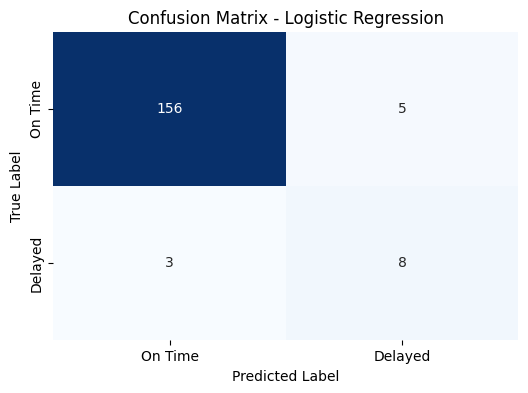

In [79]:
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['On Time', 'Delayed'],
            yticklabels=['On Time', 'Delayed'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [83]:
import numpy as np

model = GaussianNB()
model.fit(X_train, y_train)

# class priors
print("Class priors:", model.class_prior_)

# means and variances per feature per class
print("Means per class:")
print(model.theta_)
print("Variances per class:")
print(model.var_)


Class priors: [0.9371345 0.0628655]
Means per class:
[[ 3.09141771e+04  4.67129485e+01  4.62072897e+03  1.06021685e+03
   2.02433541e+03  6.73166927e+00  1.78502340e+01  2.63962559e+00
   2.59126365e+00  2.02443994e+03  7.16380655e+00  1.68642746e+01
   2.35413417e+00  2.74414977e+00  2.02434009e+03  6.85335413e+00
   1.58283931e+01  2.02808112e+00  2.65522621e+00  2.02424493e+03
   6.16692668e+00  1.49578783e+01  3.12168487e+00  2.38221529e+00
   4.69781591e+01  5.65226209e+01  5.31263651e+01 -3.39625585e+00
   3.08516381e+02]
 [ 3.11320000e+04  4.01162791e+01  5.88789302e+03  1.08344186e+03
   2.02444186e+03  7.41860465e+00  1.29069767e+01  2.55813953e+00
   2.90697674e+00  2.02458140e+03  7.60465116e+00  1.37441860e+01
   2.74418605e+00  2.93023256e+00  2.02444186e+03  7.93023256e+00
   1.47906977e+01  2.18604651e+00  3.04651163e+00  2.02444186e+03
   5.41860465e+00  1.65348837e+01  3.48837209e+00  2.13953488e+00
   4.01162791e+01  7.48837209e+01  5.73488372e+01 -1.75348837e+01
   2

In [86]:
importance = abs(model.theta_[1] - model.theta_[0]) / np.sqrt(model.var_[0] + model.var_[1])
importance_df = pd.DataFrame({'feature': X_train.columns, 'importance': importance})
importance_df.sort_values(by='importance', ascending=False, inplace=True)
print(importance_df.head(10))

                          feature  importance
27           gap_between_eta_bill    0.763668
25  gap_between_bill_and_shipment    0.582592
6                         eta_day    0.370206
18              bill_date_quarter    0.317034
15                bill_date_month    0.295140
8                     eta_quarter    0.245532
11                   due_date_day    0.240423
26        gap_between_eta_shipped    0.215908
20             shipped_date_month    0.200069
19              shipped_date_year    0.192049


<Axes: xlabel='shipment_classified'>

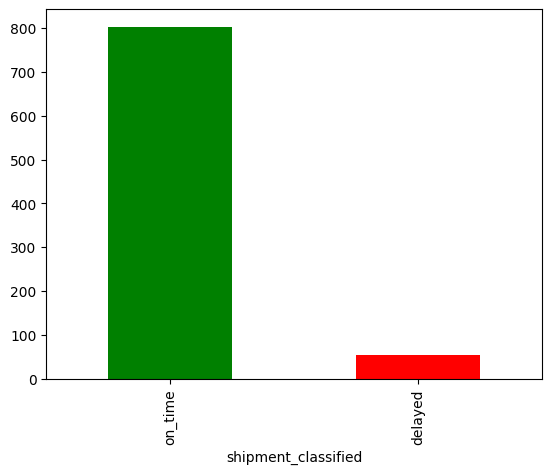

In [87]:
df['shipment_classified'].value_counts().plot(kind='bar', color=['green', 'red'])